## Experiment 06 : Decision Tree and K-Nearest Neighbour (KNN) for Classification

## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Load dataset

In [4]:
data = pd.read_csv("breast-cancer.csv")

In [5]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 569
Number of columns: 32


In [7]:
print("Column Names:")
print(data.columns.tolist())

Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [14]:
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [9]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Data preprocessing

In [10]:
print(data["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [11]:
##The id does not represent a medical feature, so we should remove it.
if "id" in data.columns:
    data = data.drop("id", axis=1)

print(data.head())

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          17.33 

## Separate input and output

In [12]:
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

print("Input features shape:", X.shape)
print("Target shape:", y.shape)

Input features shape: (569, 30)
Target shape: (569,)


In [13]:
##Convert target labels into numbers
y = y.map({"B": 0, "M": 1})
print(y.head())

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


## Check the final dataset

In [15]:
## Check missing values again
print("Missing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
0

Missing values in y:
0


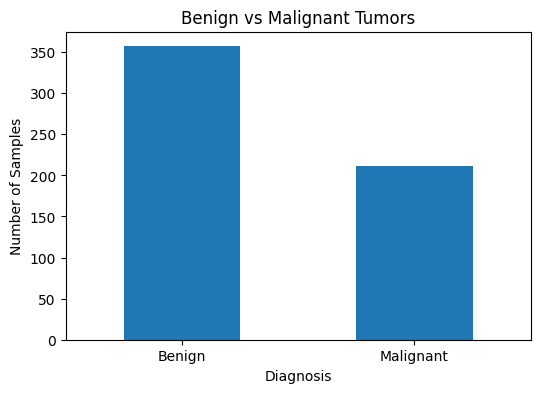

In [16]:
## Visualize class distribution
plt.figure(figsize=(6, 4))
y.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Benign vs Malignant Tumors")
plt.xticks([0, 1], ["Benign", "Malignant"], rotation=0)
plt.show()

## Train-Test Split

In [17]:
## split dataset 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## K-NEAREST NEIGHBOUR (KNN)

Feature Scaling for KNN

In [18]:
## Standardize the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed.")

Feature scaling completed.


Create KNN model

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)
print("KNN model created successfully.")

KNN model created successfully.


Train model

In [21]:
knn_model.fit(X_train_scaled, y_train)
print("KNN model trained successfully.")

KNN model trained successfully.


Make predictions

In [22]:
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN predictions:")
print(y_pred_knn[:20])

KNN predictions:
[0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0]


Calculate KNN Accuracy

In [23]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 95.61 %


Confusion Matrix

In [24]:
knn_cm = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(knn_cm)

KNN Confusion Matrix:
[[71  1]
 [ 4 38]]


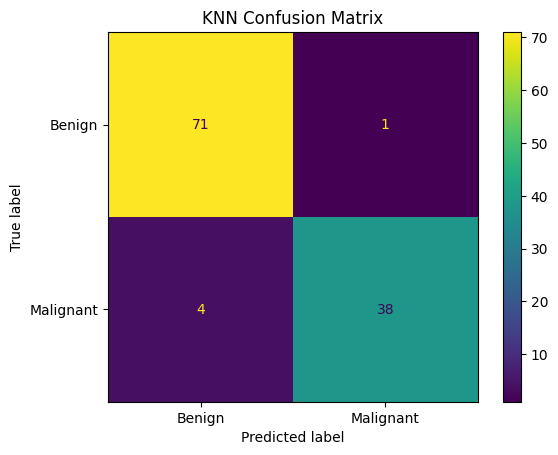

In [25]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=["Benign", "Malignant"]
)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

Classification Report

In [26]:
print("KNN Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=["Benign", "Malignant"]
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Test different K values

In [27]:
k_values = range(1, 16)
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, prediction)
    k_accuracies.append(accuracy)

print(k_accuracies)

[0.9298245614035088, 0.9122807017543859, 0.9385964912280702, 0.9385964912280702, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9385964912280702, 0.9473684210526315]


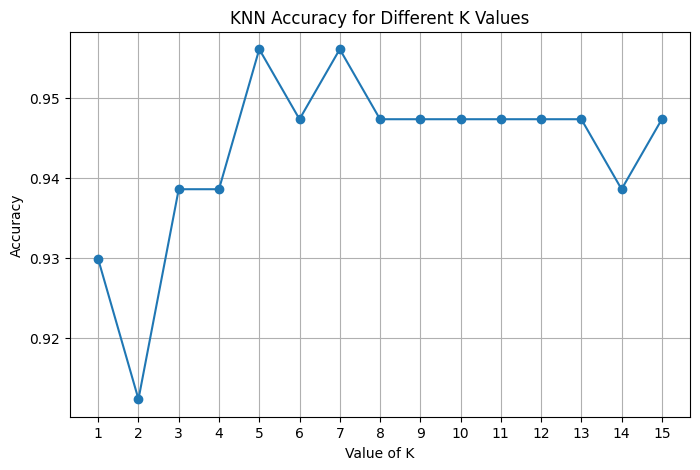

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, k_accuracies, marker="o")

plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(list(k_values))

plt.grid()
plt.show()

## Conclusion
In this experiment, K-Nearest Neighbour (KNN) and  were implemented on the Breast Cancer dataset. The dataset was divided into training and testing sets, and the performance of both algorithms was evaluated using accuracy, precision, recall, F1-score, and confusion matrix.
KNN classification was performed after standardizing the features because KNN is a distance-based algorithm. 
